<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Computational Statistics / Linear Regression</h1>
<h3 style="margin: 0;  color: #1e1a66">Samoliuk Oleksandr</h3>
</div>

Imports:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

---

In [3]:
# Ridge Regularization Example

X = np.array([[1, 2, 2, 6, 83],
              [1, 2, 2, 9, 71],
              [1, 2, 2, 3, 11]])
Cov = X.T @ X
I = np.eye(Cov.shape[0])
l = 10

np.linalg.inv(Cov + l*I)

array([[ 0.09624994, -0.00750012, -0.00750012, -0.00587027, -0.00033687],
       [-0.00750012,  0.08499977, -0.01500023, -0.01174054, -0.00067373],
       [-0.00750012, -0.01500023,  0.08499977, -0.01174054, -0.00067373],
       [-0.00587027, -0.01174054, -0.01174054,  0.049122  , -0.0040424 ],
       [-0.00033687, -0.00067373, -0.00067373, -0.0040424 ,  0.00051653]])

### Linear Regression 

In [4]:
pts = 50

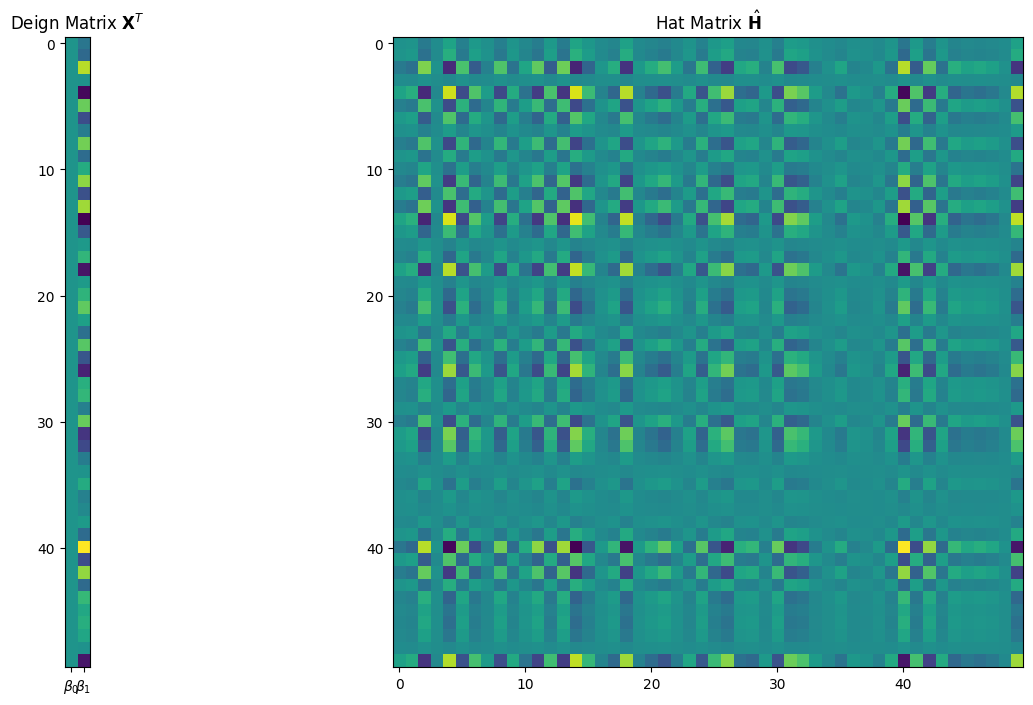

In [5]:
normal_cov = np.array([[100, 10],
                       [10,  3]]) 
normal_mean = np.array([0, 0])

rng = np.random.default_rng(33)
samples = rng.multivariate_normal(normal_mean, normal_cov, size=pts)
x, Y = samples[:,0], samples[:,1]

X = np.vstack((np.ones(pts), x)).T
H = X @ np.linalg.inv((X.T @ X)) @ X.T

beta_hat = np.linalg.inv((X.T @ X)) @ X.T @ Y
y_hat = H @ Y
residuals = Y - y_hat

#________________________________________________________________________

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, pts/7))

ax[0].imshow(X)
ax[0].set_yticks(np.arange(0, pts, 10))
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['$\\beta_0$', '$\\beta_1$'])
ax[0].set_title('Deign Matrix $\\mathbf{X}^T$')

ax[1].imshow(H)
ax[1].set_xticks(np.arange(0, pts, 10))
ax[1].set_title('Hat Matrix $\\hat{\\mathbf{H}}$')

plt.tight_layout()
plt.savefig('Outputs/Linear_regression/matrix_plots.png')
plt.show()

In [6]:
is_idempotent = np.allclose(H @ H, H)
is_symmetric  = np.allclose(H.T, H)
residuals_orthogonal = np.allclose(X.T @ residuals, np.zeros(X.shape[1]))

print(f"H is Idempotent (H² = H):   {is_idempotent}")
print(f"H is Symmetric  (Hᵀ = H):   {is_symmetric}")
print(f"Residuals Orthogonal to X:  {residuals_orthogonal}")

H is Idempotent (H² = H):   True
H is Symmetric  (Hᵀ = H):   True
Residuals Orthogonal to X:  True


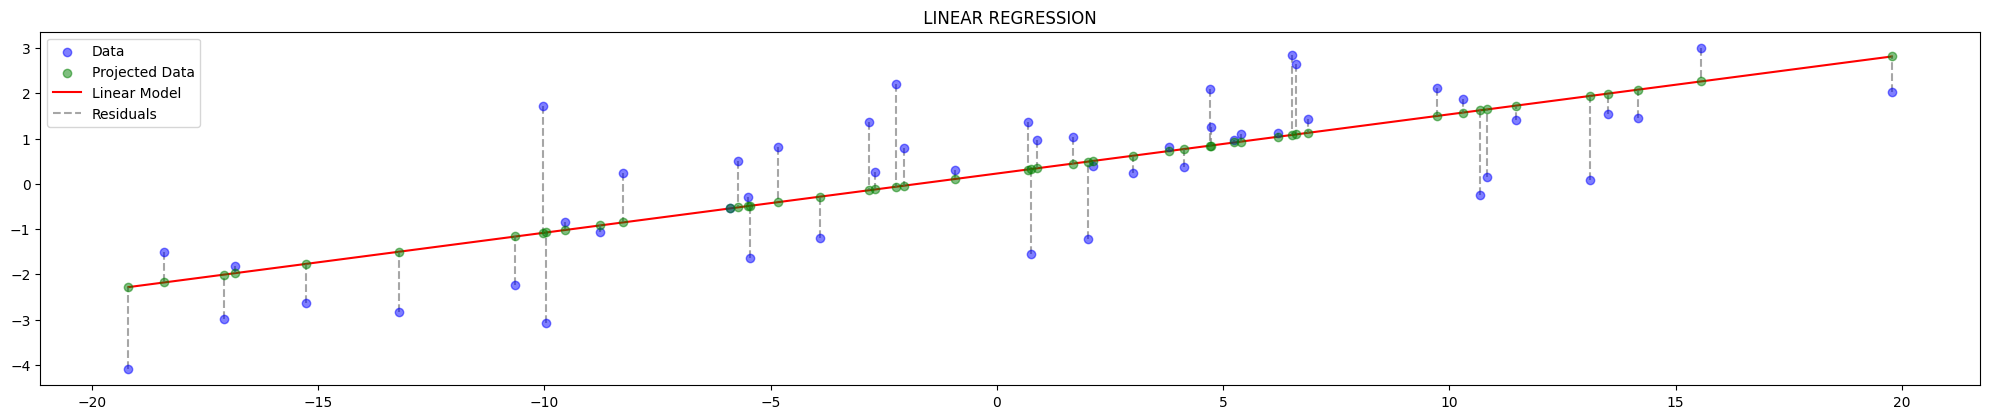

In [7]:
fig, ax = plt.subplots(figsize=(pts/2.5, 5))

ax.scatter(x, Y, c='b', alpha=0.5, label='Data',
           zorder=3)

ax.scatter(x, y_hat, c='g', alpha=0.5, label='Projected Data',
           zorder=9)

ax.plot([x.min(), x.max()],
        [y_hat.min(), y_hat.max()], 
        c='r', label='Linear Model',
        zorder=0)

ax.vlines(x, Y, y_hat, colors='gray', linestyle='--', alpha=0.7, label='Residuals', zorder=1)

ax.legend()
ax.set_aspect('equal')
plt.title(' LINEAR REGRESSION ')
plt.tight_layout()

plt.savefig('Outputs/Linear_regression/linear_regression_visual.png')
plt.show()

$$
\mathbf{R}^2 = \frac{\displaystyle \sum_i^N(\hat{y}_i - \bar{y})^2}{\displaystyle \sum_i^N(y_i - \bar{y})^2} = \frac{ESS}{TSS}
$$

In [8]:
y_mean = np.mean(Y)
ESS = np.sum((y_hat- y_mean)**2)
TSS = np.sum((Y- y_mean)**2)

R_sq = ESS/TSS
print(f"R2 = {R_sq:.5f}")

R2 = 0.55436
